In [2]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')   

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

In [4]:
import pandas as pd

sustain = pd.read_csv(r"D:\sustainability-business-case-study\dataset.csv\dataset.csv", encoding='ISO-8859-1')

ecom = pd.read_csv(r"D:\sustainability-business-case-study\data.csv\co2.csv", encoding='ISO-8859-1')

In [5]:
print("ECOM columns:", ecom.columns)
print("SUSTAIN columns:", sustain.columns)

ECOM columns: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
SUSTAIN columns: Index(['country', 'date', 'sector', 'value', 'timestamp'], dtype='object')


In [6]:
# Clean e-commerce
ecom.columns = ecom.columns.str.strip()

ecom = ecom.dropna(subset=['Description'])
ecom = ecom[ecom['Quantity'] > 0]
ecom = ecom[ecom['UnitPrice'] > 0]

ecom['InvoiceDate'] = pd.to_datetime(ecom['InvoiceDate'], format='mixed', dayfirst=True)
ecom['Revenue'] = ecom['Quantity'] * ecom['UnitPrice']

In [7]:
ecom['InvoiceDate'] = pd.to_datetime(
    ecom['InvoiceDate'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [8]:
# Clean column names (safe step)
ecom.columns = ecom.columns.str.strip()

# Remove missing values
ecom = ecom.dropna(subset=['Description'])

# Remove invalid values
ecom = ecom[ecom['Quantity'] > 0]
ecom = ecom[ecom['UnitPrice'] > 0]

# Convert date (FIXED)
ecom['InvoiceDate'] = pd.to_datetime(
    ecom['InvoiceDate'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Create Revenue
ecom['Revenue'] = ecom['Quantity'] * ecom['UnitPrice']

In [9]:
# Clean sustain dataset
sustain.columns = sustain.columns.str.strip()

# Convert date
sustain['date'] = pd.to_datetime(sustain['date'], dayfirst=True, errors='coerce')

# Remove unwanted rows
sustain = sustain[~sustain['country'].isin(['WORLD', 'ROW', 'EU27 & UK'])]

# Aggregate emissions
carbon_country = sustain.groupby('country')['value'].sum().reset_index()

In [10]:
# Revenue by country
revenue_country = ecom.groupby('Country')['Revenue'].sum().reset_index()

# Fix country names
revenue_country['Country'] = revenue_country['Country'].replace({
    'United Kingdom': 'UK',
    'United States': 'US'
})

# Merge datasets
merged_df = revenue_country.merge(
    carbon_country,
    left_on='Country',
    right_on='country',
    how='inner'
)

print(merged_df.head())

   Country    Revenue  country        value
0   Brazil    1143.60   Brazil  1836.474832
1   France  209715.11   France  1328.491333
2  Germany  228867.14  Germany  2951.018676
3    Italy   17483.24    Italy  1423.104886
4    Japan   37416.37    Japan  4722.530409


In [11]:
revenue_country = ecom.groupby('Country')['Revenue'].sum().reset_index()

In [12]:
revenue_country['Country'] = revenue_country['Country'].replace({
    'United Kingdom': 'UK',
    'United States': 'US'
})

In [13]:
carbon_country = sustain.groupby('country')['value'].sum().reset_index()

In [14]:
merged_df = revenue_country.merge(
    carbon_country,
    left_on='Country',
    right_on='country',
    how='inner'
)

print(merged_df.head())

   Country    Revenue  country        value
0   Brazil    1143.60   Brazil  1836.474832
1   France  209715.11   France  1328.491333
2  Germany  228867.14  Germany  2951.018676
3    Italy   17483.24    Italy  1423.104886
4    Japan   37416.37    Japan  4722.530409


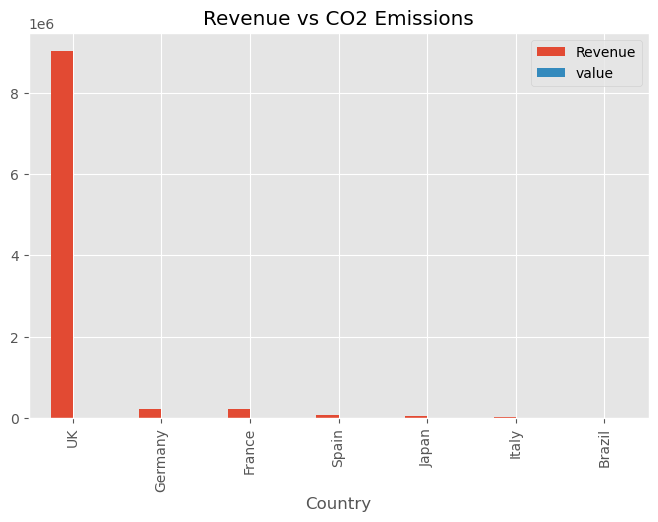

In [15]:
import matplotlib.pyplot as plt

merged_df.sort_values('Revenue', ascending=False).head(10).plot(
    x='Country', y=['Revenue', 'value'], kind='bar'
)

plt.title("Revenue vs CO2 Emissions")
plt.show()

In [16]:
# Revenue column
ecom['Revenue'] = ecom['Quantity'] * ecom['UnitPrice']

# Create Month column (you missed this earlier ❗)
ecom['Month'] = ecom['InvoiceDate'].dt.to_period('M')

In [17]:
#Revenue Overview
print(ecom['Revenue'].sum())

10666684.544


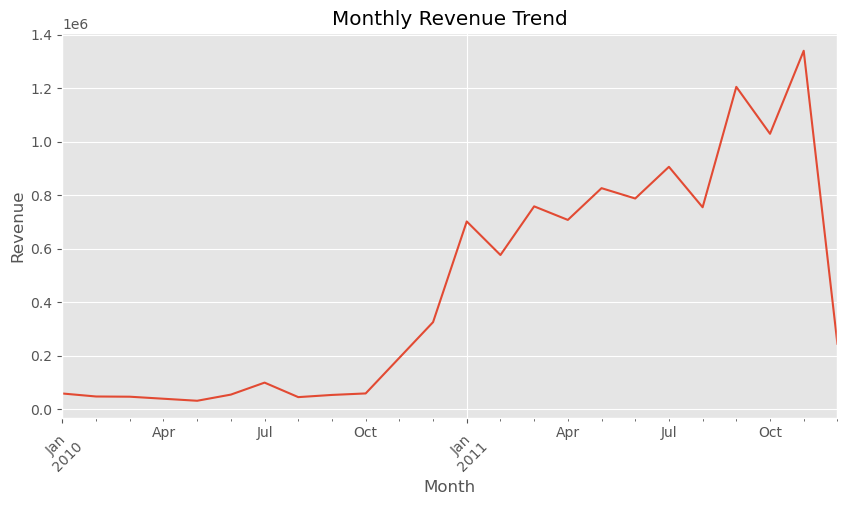

In [18]:
#Monthly Revenue Trend
monthly_rev = ecom.groupby('Month')['Revenue'].sum()

monthly_rev.plot(kind='line', figsize=(10,5))
plt.title("📈 Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

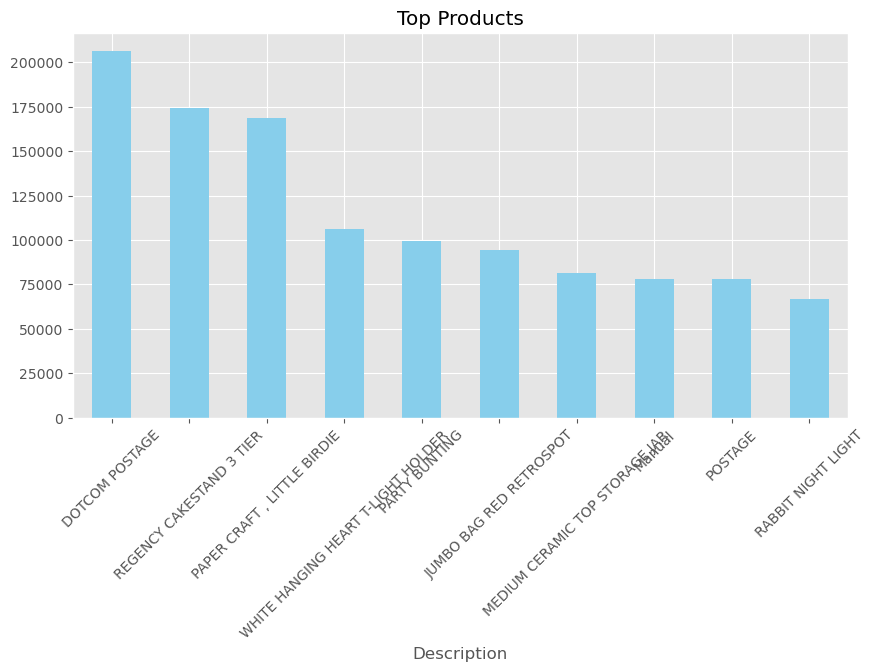

In [19]:
#Top Products
top_products = ecom.groupby('Description')['Revenue'] \
    .sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title("🛍️ Top Products", fontsize=14)
plt.xticks(rotation=45)
plt.title("Top Products")
plt.show()

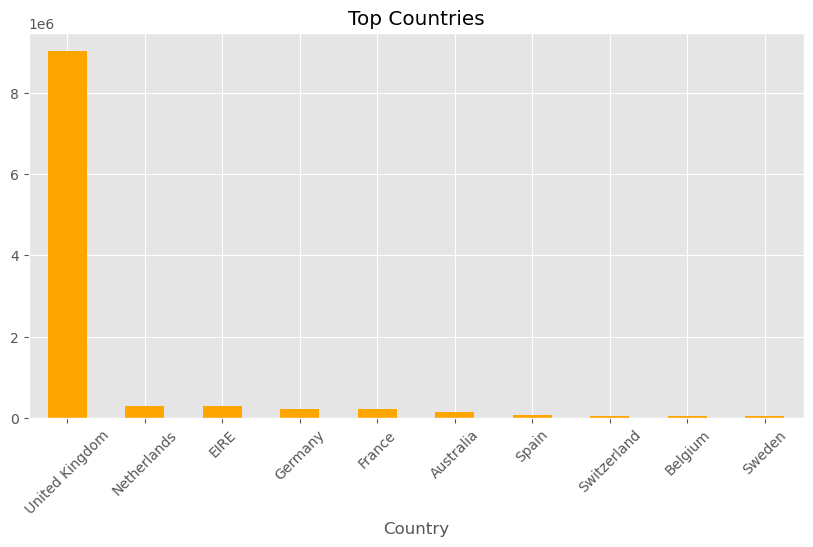

In [20]:
#Country Revenue
country_rev = ecom.groupby('Country')['Revenue'] \
    .sum().sort_values(ascending=False).head(10)

country_rev.plot(kind='bar', figsize=(10,5), color='orange')
plt.title("🌍 Top Countries by Revenue", fontsize=14)
plt.xticks(rotation=45)
plt.title("Top Countries")
plt.show()

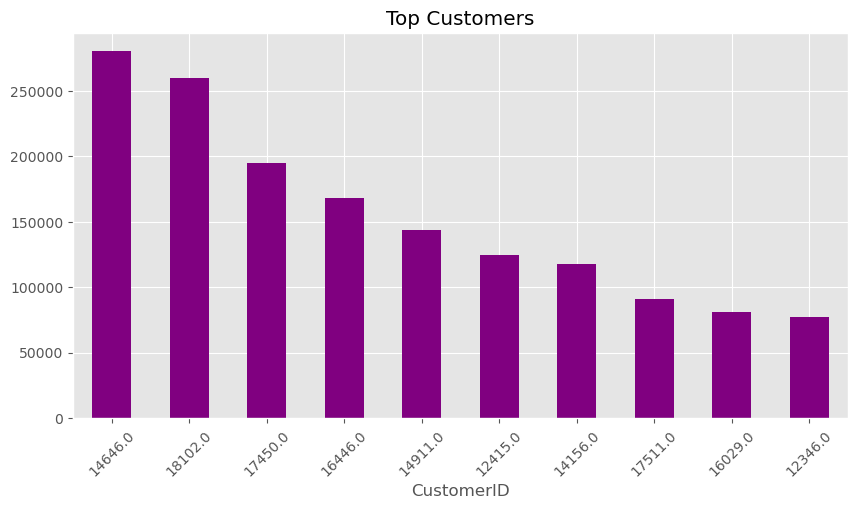

In [21]:
#Customer Revenue
customer_rev = ecom.groupby('CustomerID')['Revenue'] \
    .sum().sort_values(ascending=False).head(10)

customer_rev.plot(kind='bar', figsize=(10,5), color='purple')
plt.title("👥 Top Customers", fontsize=14)
plt.xticks(rotation=45)
plt.title("Top Customers")
plt.show()

In [22]:
#Clean Sustainability Data
sustain['date'] = pd.to_datetime(sustain['date'], dayfirst=True, errors='coerce')
sustain['Year'] = sustain['date'].dt.year

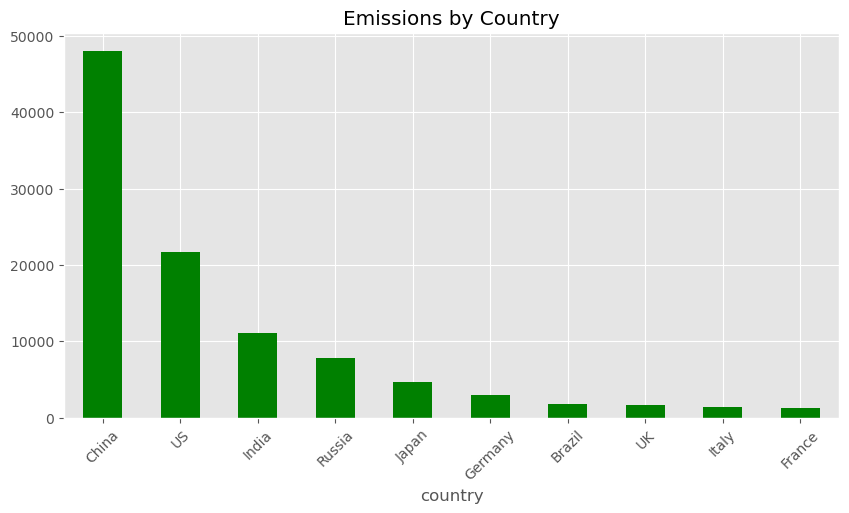

In [23]:
#Emissions by Country
emission_country = sustain.groupby('country')['value'] \
    .sum().sort_values(ascending=False)

emission_country.head(10).plot(kind='bar', figsize=(10,5), color='green')
plt.title("🌱 Emissions by Country", fontsize=14)
plt.xticks(rotation=45)
plt.title("Emissions by Country")
plt.show()

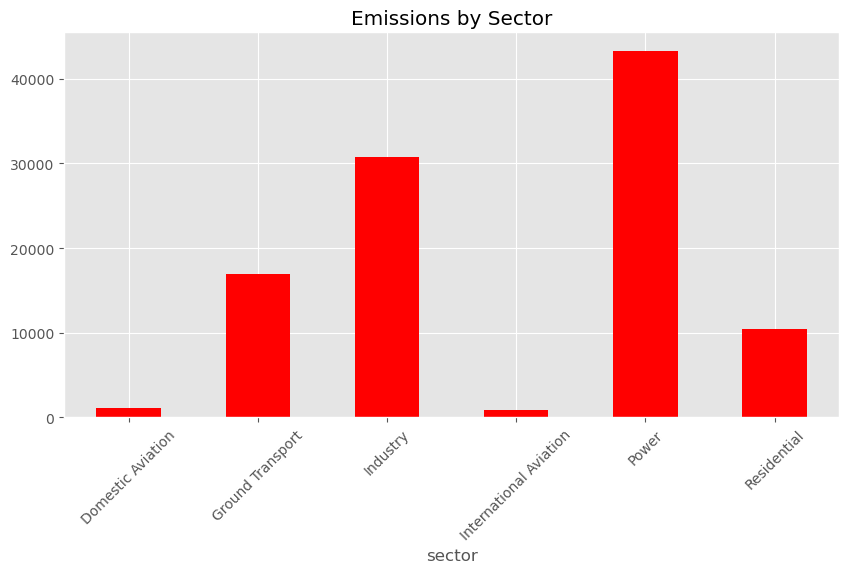

In [24]:
#Emissions by Sector
sector_data = sustain.groupby('sector')['value'].sum()

sector_data.plot(kind='bar', figsize=(10,5), color='red')
plt.title("🏭 Emissions by Sector", fontsize=14)
plt.xticks(rotation=45)
plt.title("Emissions by Sector")
plt.show()

In [25]:
#Create Eco Category
eco_keywords = ['eco', 'green', 'recycled', 'organic']

def label_product(x):
    if any(word in str(x).lower() for word in eco_keywords):
        return "Eco-Friendly"
    return "Non-Eco"

ecom['Category'] = ecom['Description'].apply(label_product)

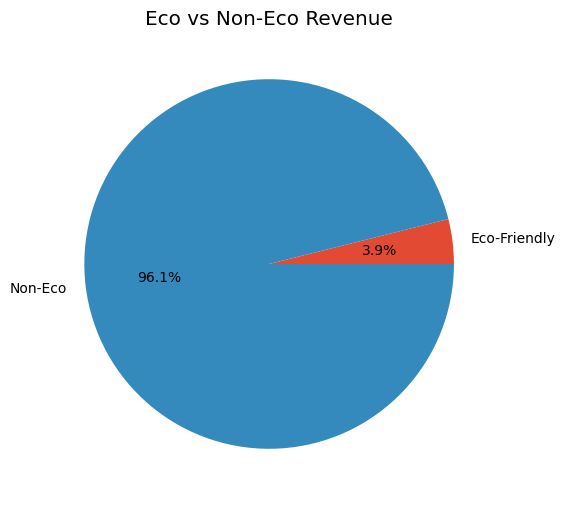

In [26]:
#Eco vs Non-Eco Revenue
eco_rev = ecom.groupby('Category')['Revenue'].sum()

eco_rev.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("♻️ Eco vs Non-Eco Revenue")
plt.ylabel("")
plt.title("Eco vs Non-Eco Revenue")
plt.show()

In [27]:
#Final Insights
print("Insights:")
print("1. Revenue concentrated in top products/customers")
print("2. Few countries dominate sales")
print("3. Emissions high in major economies")
print("4. Power sector major contributor")
print("5. Eco-products show growth opportunity")

Insights:
1. Revenue concentrated in top products/customers
2. Few countries dominate sales
3. Emissions high in major economies
4. Power sector major contributor
5. Eco-products show growth opportunity


In [28]:
#Recommendations
print("Recommendations:")
print("✔ Promote eco-friendly products")
print("✔ Reduce environmental impact")
print("✔ Target high-value customers")
print("✔ Align business with sustainability")

Recommendations:
✔ Promote eco-friendly products
✔ Reduce environmental impact
✔ Target high-value customers
✔ Align business with sustainability
